# Day 10 -- NumPy: Linear Algebra + Advanced Features + Mini Project (Unit 13 to 20)
### 90-Day Gen AI Engineer Roadmap

---
**Author:** Shaurab Kumar Jha  
**Date:** Day 10 of 90  
**Goal:** MNC-ready Python & Gen AI Engineer

## Topics Covered

| Unit | Topic |
|------|-------|
| Unit 13 | np.dot, matmul, @ operator -- matrix multiplication deep dive |
| Unit 14 | np.linalg -- inv, det, eig, svd, solve, norm, rank, lstsq |
| Unit 15 | np.einsum -- Einstein summation notation |
| Unit 16 | NaN handling -- isnan, nan_to_num, nanmean, nanstd |
| Unit 17 | Random module -- seed, shuffle, permutation, choice, distributions |
| Unit 18 | vectorize, apply_along_axis, frompyfunc |
| Unit 19 | float32 vs float64, in-place ops, memory optimization |
| Unit 20 | np.save/load, savez_compressed, masked arrays, meshgrid, plots |

**Mini Project:** Image Processing with only NumPy -- no OpenCV

---

**Why this matters for Gen AI:**
- Matrix multiply is the core of every neural network layer
- SVD powers PCA, dimensionality reduction, and image compression
- Einsum is used heavily in attention mechanism implementations
- NaN handling is critical in real-world data pipelines
- float32 vs float64 directly affects GPU memory usage
- Image as array is the foundation of all computer vision

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
print(f"NumPy version:      {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")

NumPy version:      2.3.3
Matplotlib version: 3.10.8


---
# UNIT 13 -- Matrix Multiplication: dot, matmul, @

Three ways to multiply in NumPy. Understanding which to use when is a fundamental skill for implementing neural networks.

In [3]:
# --------------------------------------------------
# Element-wise multiply vs Matrix multiply
# The most common confusion for beginners
# --------------------------------------------------

A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

# Element-wise multiply (Hadamard product)
elem_wise = A * B

# Matrix multiply -- row dot col
mat_mul = A @ B

print("A:")
print(A)
print("\nB:")
print(B)
print("\nA * B  (element-wise):")
print(elem_wise)
print("\nA @ B  (matrix multiply):")
print(mat_mul)
print("\nManual check A@B [0,0]: row0 of A dot col0 of B =",
      A[0,0]*B[0,0] + A[0,1]*B[1,0])

A:
[[1 2]
 [3 4]]

B:
[[5 6]
 [7 8]]

A * B  (element-wise):
[[ 5 12]
 [21 32]]

A @ B  (matrix multiply):
[[19 22]
 [43 50]]

Manual check A@B [0,0]: row0 of A dot col0 of B = 19


In [4]:
# --------------------------------------------------
# np.dot -- context-dependent behavior
# --------------------------------------------------

# 1D dot 1D --> scalar (inner product)
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
dot_1d = np.dot(a, b)   # 1*4 + 2*5 + 3*6 = 32
print("np.dot behavior by dimension:")
print(f"  1D dot 1D  --> scalar: {dot_1d}  (inner product: sum of element-wise products)")

# 2D dot 2D --> matrix multiply
dot_2d = np.dot(A, B)
print(f"  2D dot 2D  --> matrix multiply:")
print(dot_2d)

# 2D dot 1D --> matrix-vector product
v = np.array([1, 2])
dot_mv = np.dot(A, v)   # (2,2) @ (2,) = (2,)
print(f"  2D dot 1D  --> matrix-vector: {dot_mv}  shape: {dot_mv.shape}")

# scalar dot array --> scalar multiply
dot_scalar = np.dot(3, A)
print(f"  scalar dot 2D --> scalar multiply:")
print(dot_scalar)

# --------------------------------------------------
# np.matmul and @ operator
# --------------------------------------------------

print("\nnp.dot vs np.matmul vs @ :")
print(f"  np.dot(A,B) == np.matmul(A,B): {np.array_equal(np.dot(A,B), np.matmul(A,B))}")
print(f"  np.dot(A,B) == A @ B:          {np.array_equal(np.dot(A,B), A @ B)}")

# Key difference: np.dot treats 3D differently
# np.matmul / @ : treats 3D as stack of 2D matrices (batch)
# np.dot 3D     : sum product over last axis of first, second-to-last of second
X3 = np.ones((2, 3, 4))
Y3 = np.ones((2, 4, 5))
matmul_3d = np.matmul(X3, Y3)   # (2, 3, 5) -- 2 batch matmuls
print(f"\n3D matmul (batch): {X3.shape} @ {Y3.shape} = {matmul_3d.shape}")
print("  Treats axis 0 as batch -- does 2 independent (3,4)@(4,5) matrix multiplies")

np.dot behavior by dimension:
  1D dot 1D  --> scalar: 32  (inner product: sum of element-wise products)
  2D dot 2D  --> matrix multiply:
[[19 22]
 [43 50]]
  2D dot 1D  --> matrix-vector: [ 5 11]  shape: (2,)
  scalar dot 2D --> scalar multiply:
[[ 3  6]
 [ 9 12]]

np.dot vs np.matmul vs @ :
  np.dot(A,B) == np.matmul(A,B): True
  np.dot(A,B) == A @ B:          True

3D matmul (batch): (2, 3, 4) @ (2, 4, 5) = (2, 3, 5)
  Treats axis 0 as batch -- does 2 independent (3,4)@(4,5) matrix multiplies


In [5]:
# --------------------------------------------------
# Outer product, inner product, cross product
# --------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

inner = np.inner(a, b)           # scalar: sum(a*b)
outer = np.outer(a, b)           # (3,3) matrix
cross = np.cross(a, b)           # (3,) perpendicular vector

print("a:", a)
print("b:", b)
print(f"\nnp.inner(a,b) = {inner}   (dot product = scalar)")
print(f"\nnp.outer(a,b):  shape {outer.shape}   (each a[i]*b[j])")
print(outer)
print(f"\nnp.cross(a,b) = {cross}   (perpendicular to both)")

# Real AI use: attention score computation
# Query-Key attention: Q(seq_q, d_k) @ K.T(d_k, seq_k) = scores(seq_q, seq_k)
seq_len = 5
d_k     = 64
Q = np.random.randn(seq_len, d_k)  # query
K = np.random.randn(seq_len, d_k)  # key
V = np.random.randn(seq_len, d_k)  # value

# Scaled dot-product attention
scores = Q @ K.T / np.sqrt(d_k)    # (seq, seq)

def softmax_2d(x):
    x = x - x.max(axis=-1, keepdims=True)   # stability
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attn_weights = softmax_2d(scores)        # (seq, seq)
attn_output  = attn_weights @ V          # (seq, d_k)

print(f"\nScaled Dot-Product Attention (Transformer):")
print(f"  Q: {Q.shape}, K: {K.shape}, V: {V.shape}")
print(f"  Q @ K.T: {scores.shape}  /  sqrt({d_k}) = {scores.shape}")
print(f"  softmax: {attn_weights.shape}")
print(f"  @ V:     {attn_output.shape}")
print(f"  Attn weights row sum: {attn_weights[0].sum():.6f}  (must be 1.0)")

a: [1 2 3]
b: [4 5 6]

np.inner(a,b) = 32   (dot product = scalar)

np.outer(a,b):  shape (3, 3)   (each a[i]*b[j])
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]

np.cross(a,b) = [-3  6 -3]   (perpendicular to both)

Scaled Dot-Product Attention (Transformer):
  Q: (5, 64), K: (5, 64), V: (5, 64)
  Q @ K.T: (5, 5)  /  sqrt(64) = (5, 5)
  softmax: (5, 5)
  @ V:     (5, 64)
  Attn weights row sum: 1.000000  (must be 1.0)


---
# UNIT 14 -- np.linalg: Linear Algebra Operations

np.linalg is the powerhouse for ML math -- inverse, determinant, eigenvalues, SVD, solving linear systems.

In [6]:
# --------------------------------------------------
# Matrix Inverse and Determinant
# --------------------------------------------------

A = np.array([[4.0, 7.0],
              [2.0, 6.0]])

# Determinant
det_A = np.linalg.det(A)
print("Matrix A:")
print(A)
print(f"\nnp.linalg.det(A)  = {det_A:.4f}")
print(f"  Manual check: 4*6 - 7*2 = {4*6 - 7*2}")
print(f"  det != 0 means matrix is invertible")

# Inverse
A_inv = np.linalg.inv(A)
print(f"\nnp.linalg.inv(A):")
print(np.round(A_inv, 6))

# Verify: A @ A_inv should be identity
identity_check = A @ A_inv
print(f"\nA @ A_inv (should be identity):")
print(np.round(identity_check, 10))
print(f"Is identity? {np.allclose(identity_check, np.eye(2))}")

# Singular matrix -- no inverse
singular = np.array([[1.0, 2.0],
                     [2.0, 4.0]])   # row 2 = 2 * row 1
print(f"\nSingular matrix det: {np.linalg.det(singular):.6f}  (zero = not invertible)")
try:
    np.linalg.inv(singular)
except np.linalg.LinAlgError as e:
    print(f"LinAlgError: {e}")

# 3x3 determinant
B = np.array([[1.0, 2.0, 3.0],
              [0.0, 4.0, 5.0],
              [1.0, 0.0, 6.0]])
print(f"\n3x3 det: {np.linalg.det(B):.4f}")

Matrix A:
[[4. 7.]
 [2. 6.]]

np.linalg.det(A)  = 10.0000
  Manual check: 4*6 - 7*2 = 10
  det != 0 means matrix is invertible

np.linalg.inv(A):
[[ 0.6 -0.7]
 [-0.2  0.4]]

A @ A_inv (should be identity):
[[ 1. -0.]
 [ 0.  1.]]
Is identity? True

Singular matrix det: 0.000000  (zero = not invertible)
LinAlgError: Singular matrix

3x3 det: 22.0000


In [7]:
# --------------------------------------------------
# Eigenvalues and Eigenvectors
# Core math behind PCA, spectral clustering, PageRank
# Concept: Av = lambda*v -- vector only scales, does not rotate
# --------------------------------------------------

# Symmetric matrix -- eigenvalues always real
M = np.array([[4.0, 1.0, 0.0],
              [1.0, 3.0, 2.0],
              [0.0, 2.0, 5.0]])

eigenvalues, eigenvectors = np.linalg.eig(M)

print("Matrix M:")
print(M)
print(f"\nEigenvalues:  {np.round(eigenvalues, 4)}")
print(f"Eigenvectors (columns):")
print(np.round(eigenvectors, 4))

# Verify: M @ v = lambda * v
print("\nVerification: M @ v = lambda * v")
for i in range(len(eigenvalues)):
    v      = eigenvectors[:, i]          # i-th eigenvector
    lam    = eigenvalues[i]              # i-th eigenvalue
    lhs    = M @ v                       # M times v
    rhs    = lam * v                     # lambda times v
    match  = np.allclose(lhs, rhs)
    print(f"  v{i}: M@v = {np.round(lhs,3)}, lambda*v = {np.round(rhs,3)}, match={match}")

# Eigendecomposition: M = Q @ diag(lambda) @ Q^-1
Q   = eigenvectors
Lam = np.diag(eigenvalues)
M_reconstructed = Q @ Lam @ np.linalg.inv(Q)
print(f"\nReconstructed M from eigen decomposition:")
print(np.round(M_reconstructed, 6))
print(f"Matches original: {np.allclose(M, M_reconstructed)}")

# eigh -- for symmetric/Hermitian matrices (faster, always real)
eigvals_h, eigvecs_h = np.linalg.eigh(M)
print(f"\nnp.linalg.eigh (symmetric-optimized): eigenvalues = {np.round(eigvals_h, 4)}")

# PCA connection
print("\nPCA connection:")
print("  Covariance matrix C = X.T @ X / n")
print("  Eigenvectors of C = principal components")
print("  Eigenvalues of C  = variance explained by each PC")
np.random.seed(0)
X_data = np.random.randn(100, 3)
C = X_data.T @ X_data / len(X_data)
evals, evecs = np.linalg.eigh(C)
print(f"  Variance explained: {np.round(evals / evals.sum(), 4)}")

Matrix M:
[[4. 1. 0.]
 [1. 3. 2.]
 [0. 2. 5.]]

Eigenvalues:  [1.4711 4.1674 6.3615]
Eigenvectors (columns):
[[-0.3253 -0.9168  0.2318]
 [ 0.8227 -0.1535  0.5474]
 [-0.4662  0.3688  0.8041]]

Verification: M @ v = lambda * v
  v0: M@v = [-0.479  1.21  -0.686], lambda*v = [-0.479  1.21  -0.686], match=True
  v1: M@v = [-3.821 -0.64   1.537], lambda*v = [-3.821 -0.64   1.537], match=True
  v2: M@v = [1.475 3.482 5.115], lambda*v = [1.475 3.482 5.115], match=True

Reconstructed M from eigen decomposition:
[[ 4.  1.  0.]
 [ 1.  3.  2.]
 [-0.  2.  5.]]
Matches original: True

np.linalg.eigh (symmetric-optimized): eigenvalues = [1.4711 4.1674 6.3615]

PCA connection:
  Covariance matrix C = X.T @ X / n
  Eigenvectors of C = principal components
  Eigenvalues of C  = variance explained by each PC
  Variance explained: [0.3011 0.3148 0.3842]


In [8]:
# --------------------------------------------------
# SVD -- Singular Value Decomposition
# Most important decomposition in ML:
#   Image compression, PCA, pseudo-inverse, recommendation systems
# Formula: A = U @ diag(S) @ V.T
#   U  = left singular vectors  (m x m)
#   S  = singular values        (min(m,n),) -- always non-negative
#   Vt = right singular vectors (n x n)
# --------------------------------------------------

A = np.array([[1.0, 2.0, 3.0],
              [4.0, 5.0, 6.0],
              [7.0, 8.0, 9.0],
              [10., 11., 12.]])

# Full SVD
U, S, Vt = np.linalg.svd(A, full_matrices=True)
# Economy SVD (faster, smaller matrices)
U_econ, S_econ, Vt_econ = np.linalg.svd(A, full_matrices=False)

print("Matrix A shape:", A.shape)
print(f"\nFull SVD:")
print(f"  U shape:  {U.shape}")
print(f"  S shape:  {S.shape}   values: {np.round(S, 4)}")
print(f"  Vt shape: {Vt.shape}")
print(f"\nEconomy SVD (full_matrices=False):")
print(f"  U_econ:  {U_econ.shape}")
print(f"  S_econ:  {S_econ.shape}  values: {np.round(S_econ, 4)}")
print(f"  Vt_econ: {Vt_econ.shape}")

# Reconstruction: A = U @ diag(S) @ Vt
A_reconstructed = U_econ @ np.diag(S_econ) @ Vt_econ
print(f"\nReconstruction A = U @ diag(S) @ Vt:")
print(np.round(A_reconstructed, 6))
print(f"Matches original: {np.allclose(A, A_reconstructed)}")

# Low-rank approximation (image compression principle)
print("\nLow-rank approximation (keep only k singular values):")
for k in [1, 2, 3]:
    A_approx = U_econ[:, :k] @ np.diag(S_econ[:k]) @ Vt_econ[:k, :]
    error = np.linalg.norm(A - A_approx, 'fro')   # Frobenius norm
    variance_explained = np.sum(S_econ[:k]**2) / np.sum(S_econ**2)
    print(f"  k={k}: Frobenius error={error:.4f}  Variance explained={variance_explained:.4f}")

# Rank via SVD
rank = np.linalg.matrix_rank(A)
print(f"\nMatrix rank (via SVD threshold): {rank}")
print(f"  (A is 4x3 with linearly dependent rows, rank={rank})"
      if rank < min(A.shape) else "  (full rank)")

Matrix A shape: (4, 3)

Full SVD:
  U shape:  (4, 4)
  S shape:  (3,)   values: [25.4624  1.2907  0.    ]
  Vt shape: (3, 3)

Economy SVD (full_matrices=False):
  U_econ:  (4, 3)
  S_econ:  (3,)  values: [25.4624  1.2907  0.    ]
  Vt_econ: (3, 3)

Reconstruction A = U @ diag(S) @ Vt:
[[ 1.  2.  3.]
 [ 4.  5.  6.]
 [ 7.  8.  9.]
 [10. 11. 12.]]
Matches original: True

Low-rank approximation (keep only k singular values):
  k=1: Frobenius error=1.2907  Variance explained=0.9974
  k=2: Frobenius error=0.0000  Variance explained=1.0000
  k=3: Frobenius error=0.0000  Variance explained=1.0000

Matrix rank (via SVD threshold): 2
  (A is 4x3 with linearly dependent rows, rank=2)


In [9]:
# --------------------------------------------------
# np.linalg.solve -- Linear System Ax = b
# np.linalg.lstsq -- Least Squares (overdetermined)
# np.linalg.norm  -- Vector and Matrix norms
# --------------------------------------------------

# linalg.solve: exact solution when A is square and invertible
# System: 2x + y = 5
#         x + 3y = 10
A_sys = np.array([[2.0, 1.0],
                  [1.0, 3.0]])
b_sys = np.array([5.0, 10.0])

x_sol = np.linalg.solve(A_sys, b_sys)
print("=" * 50)
print("np.linalg.solve -- Ax = b")
print("=" * 50)
print(f"  System: 2x + y = 5, x + 3y = 10")
print(f"  Solution: x = {x_sol[0]:.4f}, y = {x_sol[1]:.4f}")
print(f"  Verify A@x: {np.round(A_sys @ x_sol, 6)}  (should be {b_sys})")
print(f"  np.allclose: {np.allclose(A_sys @ x_sol, b_sys)}")

# Prefer solve over inv for numerical stability
print(f"\n  solve is better than inv@b because:")
print(f"  np.linalg.inv(A) @ b = {np.round(np.linalg.inv(A_sys) @ b_sys, 8)}")
print(f"  np.linalg.solve(A,b) = {np.round(x_sol, 8)}  (same but numerically stable)")

# lstsq: least squares for overdetermined system (more equations than unknowns)
# Common use: linear regression via normal equations
print("\nnp.linalg.lstsq -- Least Squares")
print("Linear regression: find w minimizing ||Xw - y||^2")
np.random.seed(1)
n_pts = 20
X_reg = np.column_stack([np.ones(n_pts), np.random.randn(n_pts)])  # (20, 2) with bias
true_w = np.array([3.0, 2.0])   # intercept=3, slope=2
y_reg  = X_reg @ true_w + np.random.randn(n_pts) * 0.5

w_lstsq, residuals, rank_ls, sv_ls = np.linalg.lstsq(X_reg, y_reg, rcond=None)
print(f"  True weights:      {true_w}")
print(f"  Solved weights:    {np.round(w_lstsq, 4)}")
print(f"  Rank: {rank_ls}   Singular values: {np.round(sv_ls, 4)}")

# Norms
print("\nnp.linalg.norm")
v = np.array([3.0, 4.0])
M_norm = np.array([[1.0, 2.0], [3.0, 4.0]])
print(f"  Vector v = {v}")
print(f"  L1 norm (ord=1):     {np.linalg.norm(v, ord=1):.4f}   (sum of |elements|)")
print(f"  L2 norm (default):   {np.linalg.norm(v):.4f}   (Euclidean, sqrt(3^2+4^2)=5)")
print(f"  Linf norm (ord=inf): {np.linalg.norm(v, ord=np.inf):.4f}   (max |element|)")
print(f"  Matrix Frobenius:    {np.linalg.norm(M_norm, 'fro'):.4f}   (sqrt(sum(elem^2)))")
print(f"  Matrix spectral:     {np.linalg.norm(M_norm, 2):.4f}   (largest singular value)")

np.linalg.solve -- Ax = b
  System: 2x + y = 5, x + 3y = 10
  Solution: x = 1.0000, y = 3.0000
  Verify A@x: [ 5. 10.]  (should be [ 5. 10.])
  np.allclose: True

  solve is better than inv@b because:
  np.linalg.inv(A) @ b = [1. 3.]
  np.linalg.solve(A,b) = [1. 3.]  (same but numerically stable)

np.linalg.lstsq -- Least Squares
Linear regression: find w minimizing ||Xw - y||^2
  True weights:      [3. 2.]
  Solved weights:    [2.9746 1.9814]
  Rank: 2   Singular values: [5.0772 4.3323]

np.linalg.norm
  Vector v = [3. 4.]
  L1 norm (ord=1):     7.0000   (sum of |elements|)
  L2 norm (default):   5.0000   (Euclidean, sqrt(3^2+4^2)=5)
  Linf norm (ord=inf): 4.0000   (max |element|)
  Matrix Frobenius:    5.4772   (sqrt(sum(elem^2)))
  Matrix spectral:     5.4650   (largest singular value)


---
# UNIT 15 -- np.einsum: Einstein Summation

Einsum ek notation hai jisme ek string se complex tensor operations express karte hain.

Used heavily in: Transformer attention, tensor contractions, batched operations.

**Format:** `np.einsum('subscripts', *operands)`
- Each letter = one dimension
- Repeated letters on input side = that axis is summed over
- Letters on output side = kept in result

In [10]:
# --------------------------------------------------
# EINSUM -- from simple to complex
# --------------------------------------------------

A = np.array([[1, 2, 3],
              [4, 5, 6]])
B = np.array([[1, 2],
              [3, 4],
              [5, 6]])
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("Einsum operations -- string notation:")
print()

# Dot product: 'i,i->'
# i,i = both have same index i, -> = scalar output
dot_e = np.einsum('i,i->', a, b)
print(f"  Dot product   'i,i->'   : {dot_e}    same as np.dot({a},{b})={np.dot(a,b)}")

# Outer product: 'i,j->ij'
# i from a, j from b, no repeated -- keep both
outer_e = np.einsum('i,j->ij', a, b)
print(f"  Outer product 'i,j->ij' shape: {outer_e.shape}")
print(f"  {outer_e}")

# Element-wise multiply: 'i,i->i'
elemwise_e = np.einsum('i,i->i', a, b)
print(f"  Element-wise  'i,i->i' : {elemwise_e}   same as a*b={a*b}")

# Matrix multiply: 'ij,jk->ik'
# j is repeated (inner dimension) -- summed over
matmul_e = np.einsum('ij,jk->ik', A, B)
print(f"  Matrix multiply 'ij,jk->ik' shape: {matmul_e.shape}")
print(f"  {matmul_e}")
print(f"  Same as A@B: {np.array_equal(matmul_e, A@B)}")

# Transpose: 'ij->ji'
transpose_e = np.einsum('ij->ji', A)
print(f"  Transpose 'ij->ji' shape: {transpose_e.shape}  same as A.T: {np.array_equal(transpose_e, A.T)}")

# Trace: 'ii->'
M = np.array([[1,2,3],[4,5,6],[7,8,9]])
trace_e = np.einsum('ii->', M)
print(f"  Trace 'ii->'   : {trace_e}   same as np.trace={np.trace(M)}")

# Row sum: 'ij->i'
rowsum_e = np.einsum('ij->i', A)
print(f"  Row sum 'ij->i': {rowsum_e}   same as A.sum(axis=1)={A.sum(axis=1)}")

# Col sum: 'ij->j'
colsum_e = np.einsum('ij->j', A)
print(f"  Col sum 'ij->j': {colsum_e}   same as A.sum(axis=0)={A.sum(axis=0)}")

# Diagonal: 'ii->i'
diag_e = np.einsum('ii->i', M)
print(f"  Diagonal 'ii->i': {diag_e}   same as np.diag={np.diag(M)}")

Einsum operations -- string notation:

  Dot product   'i,i->'   : 32    same as np.dot([1 2 3],[4 5 6])=32
  Outer product 'i,j->ij' shape: (3, 3)
  [[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]
  Element-wise  'i,i->i' : [ 4 10 18]   same as a*b=[ 4 10 18]
  Matrix multiply 'ij,jk->ik' shape: (2, 2)
  [[22 28]
 [49 64]]
  Same as A@B: True
  Transpose 'ij->ji' shape: (3, 2)  same as A.T: True
  Trace 'ii->'   : 15   same as np.trace=15
  Row sum 'ij->i': [ 6 15]   same as A.sum(axis=1)=[ 6 15]
  Col sum 'ij->j': [5 7 9]   same as A.sum(axis=0)=[5 7 9]
  Diagonal 'ii->i': [1 5 9]   same as np.diag=[1 5 9]


In [11]:
# --------------------------------------------------
# EINSUM -- Batched and 3D operations (Transformer use)
# --------------------------------------------------

# Batched matrix multiply: 'bij,bjk->bik'
# b = batch, i,j,k = matrix dims
batch_A = np.random.randn(4, 3, 5)   # 4 matrices of shape (3,5)
batch_B = np.random.randn(4, 5, 2)   # 4 matrices of shape (5,2)
batch_result = np.einsum('bij,bjk->bik', batch_A, batch_B)  # (4,3,2)
print("Batched matmul 'bij,bjk->bik':")
print(f"  {batch_A.shape} @ {batch_B.shape} = {batch_result.shape}")
print(f"  Same as np.matmul: {np.allclose(batch_result, np.matmul(batch_A, batch_B))}")

# Multi-head attention score: 'bhid,bhjd->bhij'
# b=batch, h=heads, i=seq_q, j=seq_k, d=head_dim
batch = 2
heads = 4
seq   = 8
d_h   = 16
Q_mh = np.random.randn(batch, heads, seq, d_h)   # (2,4,8,16)
K_mh = np.random.randn(batch, heads, seq, d_h)   # (2,4,8,16)
attn_scores = np.einsum('bhid,bhjd->bhij', Q_mh, K_mh) / np.sqrt(d_h)
print(f"\nMulti-head attention scores 'bhid,bhjd->bhij':")
print(f"  Q: {Q_mh.shape}, K: {K_mh.shape}")
print(f"  Scores: {attn_scores.shape}  (batch, heads, seq_q, seq_k)")

# Weighted sum: 'bhij,bhjd->bhid'
V_mh = np.random.randn(batch, heads, seq, d_h)
# Apply softmax per head per query position
def softmax_last(x):
    x = x - x.max(axis=-1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)
attn_probs = softmax_last(attn_scores)
attn_out   = np.einsum('bhij,bhjd->bhid', attn_probs, V_mh)
print(f"  Attention output 'bhij,bhjd->bhid': {attn_out.shape}")

Batched matmul 'bij,bjk->bik':
  (4, 3, 5) @ (4, 5, 2) = (4, 3, 2)
  Same as np.matmul: True

Multi-head attention scores 'bhid,bhjd->bhij':
  Q: (2, 4, 8, 16), K: (2, 4, 8, 16)
  Scores: (2, 4, 8, 8)  (batch, heads, seq_q, seq_k)
  Attention output 'bhij,bhjd->bhid': (2, 4, 8, 16)


---
# UNIT 16 -- NaN Handling

Real-world data pipelines almost always contain missing values (NaN).
NumPy has specific nan-aware functions that skip NaN instead of propagating it.

In [12]:
# --------------------------------------------------
# NaN -- Not a Number
# np.nan is a float IEEE 754 special value
# --------------------------------------------------

# NaN basics
x = np.nan
print("NaN properties:")
print(f"  np.nan:              {np.nan}")
print(f"  type(np.nan):        {type(np.nan)}")
print(f"  np.nan == np.nan:    {np.nan == np.nan}   (NaN is never equal to itself!)")
print(f"  np.nan != np.nan:    {np.nan != np.nan}")
print(f"  np.nan + 5:          {np.nan + 5}   (NaN propagates)")
print(f"  np.nan * 0:          {np.nan * 0}   (still NaN)")
print(f"  np.nan > 5:          {np.nan > 5}")
print(f"  np.nan < 5:          {np.nan < 5}")

# NaN in arrays
arr = np.array([1.0, 2.0, np.nan, 4.0, np.nan, 6.0])
print(f"\nArray with NaN: {arr}")

# Detecting NaN
print(f"\nDetecting NaN:")
print(f"  np.isnan(arr):      {np.isnan(arr)}")
print(f"  np.isfinite(arr):   {np.isfinite(arr)}")
print(f"  np.isinf(arr):      {np.isinf(arr)}")
print(f"  np.isnan count:     {np.isnan(arr).sum()}")
print(f"  any NaN:            {np.any(np.isnan(arr))}")
print(f"  all valid:          {np.all(np.isfinite(arr))}")

# NaN propagation in regular functions
print(f"\nNaN propagation (regular functions):")
print(f"  np.mean(arr):       {np.mean(arr)}   (NaN propagates!)")
print(f"  np.sum(arr):        {np.sum(arr)}")
print(f"  np.min(arr):        {np.min(arr)}")

# NaN-safe functions
print(f"\nNaN-safe functions (skip NaN):")
print(f"  np.nanmean(arr):    {np.nanmean(arr):.4f}")
print(f"  np.nansum(arr):     {np.nansum(arr):.4f}")
print(f"  np.nanstd(arr):     {np.nanstd(arr):.4f}")
print(f"  np.nanvar(arr):     {np.nanvar(arr):.4f}")
print(f"  np.nanmin(arr):     {np.nanmin(arr):.4f}")
print(f"  np.nanmax(arr):     {np.nanmax(arr):.4f}")
print(f"  np.nanpercentile:   {np.nanpercentile(arr, 50):.4f}   (median ignoring NaN)")
print(f"  np.nanargmin:       {np.nanargmin(arr)}   (index of min, ignoring NaN)")
print(f"  np.nanargmax:       {np.nanargmax(arr)}   (index of max, ignoring NaN)")

NaN properties:
  np.nan:              nan
  type(np.nan):        <class 'float'>
  np.nan == np.nan:    False   (NaN is never equal to itself!)
  np.nan != np.nan:    True
  np.nan + 5:          nan   (NaN propagates)
  np.nan * 0:          nan   (still NaN)
  np.nan > 5:          False
  np.nan < 5:          False

Array with NaN: [ 1.  2. nan  4. nan  6.]

Detecting NaN:
  np.isnan(arr):      [False False  True False  True False]
  np.isfinite(arr):   [ True  True False  True False  True]
  np.isinf(arr):      [False False False False False False]
  np.isnan count:     2
  any NaN:            True
  all valid:          False

NaN propagation (regular functions):
  np.mean(arr):       nan   (NaN propagates!)
  np.sum(arr):        nan
  np.min(arr):        nan

NaN-safe functions (skip NaN):
  np.nanmean(arr):    3.2500
  np.nansum(arr):     13.0000
  np.nanstd(arr):     1.9203
  np.nanvar(arr):     3.6875
  np.nanmin(arr):     1.0000
  np.nanmax(arr):     6.0000
  np.nanpercentile:  

In [13]:
# --------------------------------------------------
# nan_to_num, NaN replacement strategies
# Real ML use: imputation before model training
# --------------------------------------------------

arr = np.array([1.0, np.nan, 3.0, np.nan, 5.0, np.inf, -np.inf])
print("Array:", arr)

# nan_to_num -- replace NaN, +inf, -inf with numbers
clean1 = np.nan_to_num(arr)                          # defaults: nan=0, inf=large, -inf=-large
clean2 = np.nan_to_num(arr, nan=0.0, posinf=999.0, neginf=-999.0)
print(f"\nnp.nan_to_num(arr):                     {clean1}")
print(f"nan_to_num(nan=0, posinf=999):          {clean2}")

# Manual imputation strategies
data = np.array([2.0, np.nan, 4.0, np.nan, 6.0, np.nan, 8.0])

# Strategy 1: replace with mean
mean_fill = data.copy()
mean_fill[np.isnan(mean_fill)] = np.nanmean(mean_fill)

# Strategy 2: replace with median
median_fill = data.copy()
median_fill[np.isnan(median_fill)] = np.nanmedian(data)

# Strategy 3: replace with 0
zero_fill = np.where(np.isnan(data), 0.0, data)

# Strategy 4: forward fill (use previous value)
ffill = data.copy()
for i in range(1, len(ffill)):
    if np.isnan(ffill[i]):
        ffill[i] = ffill[i-1]

print(f"\nOriginal:      {data}")
print(f"Mean fill:     {mean_fill}")
print(f"Median fill:   {median_fill}")
print(f"Zero fill:     {zero_fill}")
print(f"Forward fill:  {ffill}")

# 2D NaN handling
mat = np.array([[1.0, np.nan, 3.0],
                [np.nan, 5.0, 6.0],
                [7.0, 8.0, np.nan]])
print(f"\n2D NaN handling:")
print("Matrix:"); print(mat)
print(f"nanmean axis=0 (per col): {np.nanmean(mat, axis=0)}")
print(f"nanmean axis=1 (per row): {np.nanmean(mat, axis=1)}")
# Replace each NaN with column mean
col_means = np.nanmean(mat, axis=0)
mat_filled = mat.copy()
for col in range(mat.shape[1]):
    mat_filled[np.isnan(mat_filled[:, col]), col] = col_means[col]
print("After column-mean imputation:")
print(mat_filled)

Array: [  1.  nan   3.  nan   5.  inf -inf]

np.nan_to_num(arr):                     [ 1.00000000e+000  0.00000000e+000  3.00000000e+000  0.00000000e+000
  5.00000000e+000  1.79769313e+308 -1.79769313e+308]
nan_to_num(nan=0, posinf=999):          [   1.    0.    3.    0.    5.  999. -999.]

Original:      [ 2. nan  4. nan  6. nan  8.]
Mean fill:     [2. 5. 4. 5. 6. 5. 8.]
Median fill:   [2. 5. 4. 5. 6. 5. 8.]
Zero fill:     [2. 0. 4. 0. 6. 0. 8.]
Forward fill:  [2. 2. 4. 4. 6. 6. 8.]

2D NaN handling:
Matrix:
[[ 1. nan  3.]
 [nan  5.  6.]
 [ 7.  8. nan]]
nanmean axis=0 (per col): [4.  6.5 4.5]
nanmean axis=1 (per row): [2.  5.5 7.5]
After column-mean imputation:
[[1.  6.5 3. ]
 [4.  5.  6. ]
 [7.  8.  4.5]]


---
# UNIT 17 -- Random Module: Complete Guide

Two APIs:
- **Legacy:** `np.random.seed()`, `np.random.rand()` etc. -- older code uses this
- **Modern (recommended):** `np.random.default_rng()` -- better statistical properties, thread-safe

In [14]:
# --------------------------------------------------
# SEED -- reproducibility
# --------------------------------------------------

# Legacy API
np.random.seed(42)
legacy1 = np.random.randn(3)
np.random.seed(42)   # reset
legacy2 = np.random.randn(3)
print("Legacy seed:")
print(f"  Run 1: {legacy1}")
print(f"  Run 2: {legacy2}")
print(f"  Same:  {np.array_equal(legacy1, legacy2)}")

# Modern API -- recommended
rng1 = np.random.default_rng(seed=42)
rng2 = np.random.default_rng(seed=42)
modern1 = rng1.standard_normal(3)
modern2 = rng2.standard_normal(3)
print(f"\nModern RNG:")
print(f"  RNG 1: {modern1}")
print(f"  RNG 2: {modern2}")
print(f"  Same:  {np.array_equal(modern1, modern2)}")

# Why modern is better
print(f"\nWhy default_rng is preferred:")
print(f"  1. Thread-safe (each thread can have its own RNG)")
print(f"  2. Better statistical properties (PCG64 algorithm)")
print(f"  3. More explicit -- state is in the object, not global")
print(f"  4. np.random.seed() affects all code globally -- dangerous")

Legacy seed:
  Run 1: [ 0.49671415 -0.1382643   0.64768854]
  Run 2: [ 0.49671415 -0.1382643   0.64768854]
  Same:  True

Modern RNG:
  RNG 1: [ 0.30471708 -1.03998411  0.7504512 ]
  RNG 2: [ 0.30471708 -1.03998411  0.7504512 ]
  Same:  True

Why default_rng is preferred:
  1. Thread-safe (each thread can have its own RNG)
  2. Better statistical properties (PCG64 algorithm)
  3. More explicit -- state is in the object, not global
  4. np.random.seed() affects all code globally -- dangerous


In [15]:
# --------------------------------------------------
# shuffle, permutation, choice
# --------------------------------------------------

rng = np.random.default_rng(seed=0)
arr = np.arange(1, 11)
print("Original array:", arr)

# shuffle -- in-place, returns None
arr_s = arr.copy()
np.random.shuffle(arr_s)   # legacy
print(f"np.random.shuffle (in-place): {arr_s}")

# permutation -- returns new shuffled array (copy)
perm = np.random.permutation(arr)
perm_rng = rng.permutation(arr)   # modern
print(f"np.random.permutation (copy): {perm}")
print(f"rng.permutation (copy):       {perm_rng}")
print(f"Original unchanged:           {arr}")

# permutation on integer -- generates shuffled indices
idx_perm = rng.permutation(10)   # shuffled 0..9
print(f"\nrng.permutation(10) -- shuffled indices: {idx_perm}")
print(f"Use case: dataset shuffle")
X_data = np.arange(50).reshape(10, 5)
shuffled_X = X_data[idx_perm]   # fancy indexing with shuffled indices
print(f"Shuffled dataset rows: {shuffled_X[:3, 0]}... (first col of first 3 rows)")

# choice -- random sampling
population = np.arange(100)

s_wo_replace = rng.choice(population, size=5, replace=False)  # no repeat
s_w_replace  = rng.choice(population, size=5, replace=True)   # allow repeat
s_weighted   = rng.choice(5, size=10, p=[0.5, 0.2, 0.15, 0.1, 0.05])  # with probability

print(f"\nchoice without replacement (5 from 100): {s_wo_replace}")
print(f"choice with replacement    (5 from 100): {s_w_replace}")
print(f"choice with probability    (10 from 5):  {s_weighted}")
print(f"  (class 0 sampled most -- p=0.5)")

# Real ML: stratified mini-batch sampling
labels = np.array([0]*50 + [1]*30 + [2]*20)
batch_size = 30
batch_idx  = rng.choice(len(labels), size=batch_size, replace=False)
batch_labels = labels[batch_idx]
unique, counts = np.unique(batch_labels, return_counts=True)
print(f"\nMini-batch label distribution (size={batch_size}):")
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt}")

Original array: [ 1  2  3  4  5  6  7  8  9 10]
np.random.shuffle (in-place): [ 1  2  6  4  5  8  9 10  3  7]
np.random.permutation (copy): [10  3  1  7  9  6  4  8  2  5]
rng.permutation (copy):       [ 5  7  3  8  4  6 10  1  9  2]
Original unchanged:           [ 1  2  3  4  5  6  7  8  9 10]

rng.permutation(10) -- shuffled indices: [2 9 3 6 0 4 8 7 5 1]
Use case: dataset shuffle
Shuffled dataset rows: [10 45 15]... (first col of first 3 rows)

choice without replacement (5 from 100): [ 3 72 74 84 53]
choice with replacement    (5 from 100): [54  8 29 48 42]
choice with probability    (10 from 5):  [0 0 1 1 1 0 4 4 1 1]
  (class 0 sampled most -- p=0.5)

Mini-batch label distribution (size=30):
  Class 0: 16
  Class 1: 11
  Class 2: 3


---
# UNIT 18 -- vectorize, apply_along_axis, frompyfunc

In [16]:
# --------------------------------------------------
# np.vectorize -- apply Python function element-wise
# Note: NOT actually faster than loops, it is syntactic sugar.
# Use only when function cannot be written with ufuncs.
# --------------------------------------------------

# Without vectorize -- function only works on scalars
def grade_label(score):
    if score >= 90: return "A"
    elif score >= 80: return "B"
    elif score >= 70: return "C"
    elif score >= 60: return "D"
    else: return "F"

scores = np.array([95, 82, 67, 55, 91, 73, 88, 42])

# This would fail without vectorize
# grade_label(scores)  -- TypeError: ambiguous truth value

# With vectorize -- works on arrays
grade_vec = np.vectorize(grade_label)
grades = grade_vec(scores)
print("np.vectorize demo:")
print(f"  Scores: {scores}")
print(f"  Grades: {grades}")

# vectorize with excluded arguments
def clip_custom(x, lo, hi):
    return max(lo, min(hi, x))

clip_vec = np.vectorize(clip_custom, excluded=['lo', 'hi'])
arr_raw = np.array([-5, 3, 10, -1, 7, 15, 2])
arr_clipped = clip_vec(arr_raw, lo=0, hi=8)
print(f"\nvectorize with excluded args:")
print(f"  Raw:     {arr_raw}")
print(f"  Clipped: {arr_clipped}")

# Speed comparison -- vectorize is NOT fast
import time
large = np.random.randn(100_000)

t0 = time.perf_counter()
result_vec = np.vectorize(lambda x: x**2 + 2*x + 1)(large)
t_vec = time.perf_counter() - t0

t0 = time.perf_counter()
result_ufunc = large**2 + 2*large + 1
t_ufunc = time.perf_counter() - t0

print(f"\nSpeed comparison (100K elements):")
print(f"  np.vectorize:  {t_vec*1000:.2f} ms")
print(f"  ufunc (direct): {t_ufunc*1000:.2f} ms")
print(f"  Speedup: {t_vec/t_ufunc:.1f}x  -- vectorize is slower!")
print(f"  Use vectorize only when ufunc expression is not possible.")

np.vectorize demo:
  Scores: [95 82 67 55 91 73 88 42]
  Grades: ['A' 'B' 'D' 'F' 'A' 'C' 'B' 'F']

vectorize with excluded args:
  Raw:     [-5  3 10 -1  7 15  2]
  Clipped: [0 3 8 0 7 8 2]

Speed comparison (100K elements):
  np.vectorize:  33.79 ms
  ufunc (direct): 1.59 ms
  Speedup: 21.2x  -- vectorize is slower!
  Use vectorize only when ufunc expression is not possible.


In [17]:
# --------------------------------------------------
# np.apply_along_axis -- apply function along one axis
# Better than vectorize for row-wise or column-wise operations
# --------------------------------------------------

data = np.array([[4, 1, 8, 3],
                 [9, 2, 5, 7],
                 [6, 3, 1, 4]])
print("Data:")
print(data)

# Apply function to each row (axis=1)
def normalize_row(row):
    """Min-max normalize a single row"""
    return (row - row.min()) / (row.max() - row.min() + 1e-8)

normalized = np.apply_along_axis(normalize_row, axis=1, arr=data)
print(f"\nnp.apply_along_axis (normalize each row, axis=1):")
print(np.round(normalized, 4))

# Apply to each column (axis=0)
def standardize_col(col):
    return (col - col.mean()) / (col.std() + 1e-8)

standardized = np.apply_along_axis(standardize_col, axis=0, arr=data)
print(f"\nnp.apply_along_axis (standardize each col, axis=0):")
print(np.round(standardized, 4))

# Custom aggregation along axis
def range_iqr(arr):
    """Return IQR of a 1D array"""
    return np.percentile(arr, 75) - np.percentile(arr, 25)

iqr_per_col = np.apply_along_axis(range_iqr, axis=0, arr=data)
print(f"\nIQR per column: {iqr_per_col}")

# np.frompyfunc -- lower level, returns object array
def power_of_two(x):
    return 2 ** x

pow2_ufunc = np.frompyfunc(power_of_two, nin=1, nout=1)
result = pow2_ufunc(np.arange(8)).astype(int)
print(f"\nnp.frompyfunc demo (2^x):")
print(f"  Input:  {np.arange(8)}")
print(f"  Output: {result}")

Data:
[[4 1 8 3]
 [9 2 5 7]
 [6 3 1 4]]

np.apply_along_axis (normalize each row, axis=1):
[[0.4286 0.     1.     0.2857]
 [1.     0.     0.4286 0.7143]
 [1.     0.4    0.     0.6   ]]

np.apply_along_axis (standardize each col, axis=0):
[[-1.1355 -1.2247  1.1625 -0.9806]
 [ 1.2978  0.      0.1162  1.3728]
 [-0.1622  1.2247 -1.2787 -0.3922]]

IQR per column: [2.5 1.  3.5 2. ]

np.frompyfunc demo (2^x):
  Input:  [0 1 2 3 4 5 6 7]
  Output: [  1   2   4   8  16  32  64 128]


---
# UNIT 19 -- Memory Optimization: float32 vs float64, In-place Operations

In [18]:
# --------------------------------------------------
# float32 vs float64 -- memory and precision tradeoff
# This is critical for GPU training
# --------------------------------------------------

n = 1_000_000
arr_f32 = np.random.randn(n).astype(np.float32)
arr_f64 = np.random.randn(n).astype(np.float64)

print("=" * 55)
print("float32 vs float64 -- Memory Comparison")
print("=" * 55)
print(f"  Array size: {n:,} elements")
print(f"  float32: {arr_f32.nbytes / 1024**2:.2f} MB  ({arr_f32.itemsize} bytes/element)")
print(f"  float64: {arr_f64.nbytes / 1024**2:.2f} MB  ({arr_f64.itemsize} bytes/element)")
print(f"  Ratio: float64 uses {arr_f64.nbytes / arr_f32.nbytes:.1f}x more memory")

# Precision difference
pi_f32 = np.float32(np.pi)
pi_f64 = np.float64(np.pi)
print(f"\nPrecision:")
print(f"  float32(pi): {pi_f32}  ({pi_f32 - np.pi:.2e} error)")
print(f"  float64(pi): {pi_f64}  ({pi_f64 - np.pi:.2e} error)")

# Typical dtype for different scenarios
print(f"\nRecommended dtypes:")
print(f"  Image pixels (0-255):       uint8   (1 byte, saves 8x vs float64)")
print(f"  Neural net weights:         float32 (good precision, GPU native)")
print(f"  Mixed precision training:   float16 (2x speed on GPU, 4x less memory)")
print(f"  Scientific computation:     float64 (max precision)")
print(f"  Class labels:               int32/int64")
print(f"  Attention masks:            bool (1 bit logical, stored as uint8)")

# Speed comparison
import time
size = (1000, 1000)
M_f32 = np.random.randn(*size).astype(np.float32)
M_f64 = np.random.randn(*size).astype(np.float64)

t0 = time.perf_counter()
for _ in range(5): _ = M_f32 @ M_f32.T
t_f32 = (time.perf_counter() - t0) / 5

t0 = time.perf_counter()
for _ in range(5): _ = M_f64 @ M_f64.T
t_f64 = (time.perf_counter() - t0) / 5

print(f"\nMatmul speed (1000x1000 matrix):")
print(f"  float32: {t_f32*1000:.2f} ms")
print(f"  float64: {t_f64*1000:.2f} ms")
print(f"  float32 speedup: {t_f64/t_f32:.2f}x")

float32 vs float64 -- Memory Comparison
  Array size: 1,000,000 elements
  float32: 3.81 MB  (4 bytes/element)
  float64: 7.63 MB  (8 bytes/element)
  Ratio: float64 uses 2.0x more memory

Precision:
  float32(pi): 3.1415927410125732  (0.00e+00 error)
  float64(pi): 3.141592653589793  (0.00e+00 error)

Recommended dtypes:
  Image pixels (0-255):       uint8   (1 byte, saves 8x vs float64)
  Neural net weights:         float32 (good precision, GPU native)
  Mixed precision training:   float16 (2x speed on GPU, 4x less memory)
  Scientific computation:     float64 (max precision)
  Class labels:               int32/int64
  Attention masks:            bool (1 bit logical, stored as uint8)

Matmul speed (1000x1000 matrix):
  float32: 6.37 ms
  float64: 12.79 ms
  float32 speedup: 2.01x


In [19]:
# --------------------------------------------------
# In-place operations -- memory efficient
# Use += -= *= /= instead of creating new arrays
# --------------------------------------------------

print("In-place operations -- avoid creating extra arrays")
print()

a = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
print(f"  Original id: {id(a)}")

# Out-of-place -- creates new array
b = a + 10   # new array
print(f"  b = a + 10   id(b): {id(b)}  (different object, new memory)")

# In-place -- modifies existing
a += 10
print(f"  a += 10      id(a): {id(a)}  (same object!)")
print(f"  a: {a}")

# All in-place operators
arr = np.ones(5)
arr += 2    ;  print(f"  arr += 2:   {arr}")
arr -= 1    ;  print(f"  arr -= 1:   {arr}")
arr *= 3    ;  print(f"  arr *= 3:   {arr}")
arr /= 2    ;  print(f"  arr /= 2:   {arr}")
arr **= 2   ;  print(f"  arr **= 2:  {arr}")

# np.add(a, b, out=a) -- explicit out parameter
x = np.array([1.0, 2.0, 3.0])
y = np.array([4.0, 5.0, 6.0])
np.add(x, y, out=x)   # writes result back into x
print(f"\n  np.add(x, y, out=x): {x}  (x updated in-place)")

# In-place with ufuncs
arr = np.array([1.0, 4.0, 9.0, 16.0])
np.sqrt(arr, out=arr)   # sqrt in-place
print(f"  np.sqrt(arr, out=arr): {arr}")

# Warning: in-place on view -- dangerous!
original = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
view = original[1:4]
view += 100
print(f"\nIn-place on view:")
print(f"  view += 100")
print(f"  view:     {view}")
print(f"  original: {original}  (original changed because view shares memory!)")

In-place operations -- avoid creating extra arrays

  Original id: 2853451079600
  b = a + 10   id(b): 2853451083632  (different object, new memory)
  a += 10      id(a): 2853451079600  (same object!)
  a: [11. 12. 13. 14. 15.]
  arr += 2:   [3. 3. 3. 3. 3.]
  arr -= 1:   [2. 2. 2. 2. 2.]
  arr *= 3:   [6. 6. 6. 6. 6.]
  arr /= 2:   [3. 3. 3. 3. 3.]
  arr **= 2:  [9. 9. 9. 9. 9.]

  np.add(x, y, out=x): [5. 7. 9.]  (x updated in-place)
  np.sqrt(arr, out=arr): [1. 2. 3. 4.]

In-place on view:
  view += 100
  view:     [102. 103. 104.]
  original: [  1. 102. 103. 104.   5.]  (original changed because view shares memory!)


---
# UNIT 20 -- File I/O, Masked Arrays, Meshgrid, Plots

In [20]:
# --------------------------------------------------
# np.save, np.load, np.savez, np.savez_compressed
# --------------------------------------------------

import os

arr1 = np.random.randn(100, 50).astype(np.float32)
arr2 = np.arange(1000)
arr3 = np.eye(20)

# np.save -- single array, .npy format
np.save('/tmp/array1.npy', arr1)
loaded1 = np.load('/tmp/array1.npy')
print("np.save / np.load:")
print(f"  Saved shape:  {arr1.shape}  dtype: {arr1.dtype}")
print(f"  Loaded shape: {loaded1.shape}  dtype: {loaded1.dtype}")
print(f"  Match: {np.array_equal(arr1, loaded1)}")
print(f"  File size: {os.path.getsize('/tmp/array1.npy') / 1024:.1f} KB")

# np.savez -- multiple arrays, .npz format (uncompressed zip)
np.savez('/tmp/arrays.npz', embeddings=arr1, labels=arr2, weights=arr3)
npz = np.load('/tmp/arrays.npz')
print(f"\nnp.savez / np.load:")
print(f"  Keys in .npz: {list(npz.keys())}")
print(f"  embeddings shape: {npz['embeddings'].shape}")
print(f"  labels shape:     {npz['labels'].shape}")
print(f"  File size: {os.path.getsize('/tmp/arrays.npz') / 1024:.1f} KB")

# np.savez_compressed -- like savez but compressed
np.savez_compressed('/tmp/arrays_compressed.npz', embeddings=arr1, labels=arr2)
print(f"\nnp.savez_compressed:")
print(f"  Uncompressed: {os.path.getsize('/tmp/arrays.npz') / 1024:.1f} KB")
print(f"  Compressed:   {os.path.getsize('/tmp/arrays_compressed.npz') / 1024:.1f} KB")

# savetxt / loadtxt -- human-readable CSV format
small = np.arange(12).reshape(3, 4)
np.savetxt('/tmp/data.csv', small, delimiter=',', fmt='%d', header='c0,c1,c2,c3')
loaded_csv = np.loadtxt('/tmp/data.csv', delimiter=',', skiprows=1)
print(f"\nnp.savetxt / loadtxt (CSV):")
print(f"  Original:\n{small}")
print(f"  Loaded:\n{loaded_csv.astype(int)}")
print(f"  Match: {np.array_equal(small, loaded_csv)}")

# Clean up
for f in ['/tmp/array1.npy', '/tmp/arrays.npz', '/tmp/arrays_compressed.npz', '/tmp/data.csv']:
    os.remove(f)

np.save / np.load:
  Saved shape:  (100, 50)  dtype: float32
  Loaded shape: (100, 50)  dtype: float32
  Match: True
  File size: 19.7 KB

np.savez / np.load:
  Keys in .npz: ['embeddings', 'labels', 'weights']
  embeddings shape: (100, 50)
  labels shape:     (1000,)
  File size: 31.2 KB

np.savez_compressed:
  Uncompressed: 31.2 KB
  Compressed:   20.0 KB

np.savetxt / loadtxt (CSV):
  Original:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
  Loaded:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
  Match: True


PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: '/tmp/arrays.npz'

In [24]:
# --------------------------------------------------
# Masked Arrays -- mark specific values as invalid
# Useful when NaN replacement is not desired
# --------------------------------------------------

import numpy.ma as ma

data = np.array([1.0, -999.0, 3.0, 4.0, -999.0, 6.0, 7.0])
mask = data == -999.0   # -999 is sentinel for missing

# Create masked array
masked = ma.masked_array(data, mask=mask)
masked2 = ma.masked_where(data < 0, data)   # mask all negatives
masked3 = ma.masked_equal(data, -999.0)     # mask specific value

print("Masked Arrays:")
print(f"  Original data: {data}")
print(f"  Masked array:  {masked}   (-- = masked)")
print(f"  Masked mask:   {masked.mask}")
print(f"\n  Operations on masked array (masked values ignored):")
print(f"  mean:    {masked.mean():.4f}   (vs {data.mean():.4f} with -999 included)")
print(f"  sum:     {masked.sum():.4f}")
print(f"  count valid: {masked.count()}")

# Fill masked values
filled_mean = masked.filled(fill_value=masked.mean())
filled_zero = masked.filled(fill_value=0)
print(f"\n  filled with mean: {np.round(filled_mean, 2)}")
print(f"  filled with 0:    {filled_zero}")

# 2D masked
mat = np.array([[1, 2, 999], [4, 999, 6], [7, 8, 9]])
masked_mat = ma.masked_equal(mat, 999)
print(f"\n2D masked:")
print(masked_mat)
print(f"  Column means: {masked_mat.mean(axis=0)}")

Masked Arrays:
  Original data: [   1. -999.    3.    4. -999.    6.    7.]
  Masked array:  [1.0 -- 3.0 4.0 -- 6.0 7.0]   (-- = masked)
  Masked mask:   [False  True False False  True False False]

  Operations on masked array (masked values ignored):
  mean:    4.2000   (vs -282.4286 with -999 included)
  sum:     21.0000
  count valid: 5

  filled with mean: [1.  4.2 3.  4.  4.2 6.  7. ]
  filled with 0:    [1. 0. 3. 4. 0. 6. 7.]

2D masked:
[[1 2 --]
 [4 -- 6]
 [7 8 9]]
  Column means: [4.0 5.0 7.5]


In [25]:
# --------------------------------------------------
# np.meshgrid -- create coordinate grids
# Use: decision boundary plots, 2D function visualization
# --------------------------------------------------

# 1D inputs
x = np.linspace(-3, 3, 7)
y = np.linspace(-2, 2, 5)

XX, YY = np.meshgrid(x, y)
print("np.meshgrid:")
print(f"  x shape: {x.shape}   y shape: {y.shape}")
print(f"  XX shape: {XX.shape}   YY shape: {YY.shape}")
print(f"  XX[0,:] = {XX[0,:]}  (x values repeat across rows)")
print(f"  YY[:,0] = {YY[:,0]}  (y values repeat across cols)")

# Compute function on grid
Z = np.sin(XX) * np.cos(YY)
print(f"  Z = sin(x)*cos(y) shape: {Z.shape}")

# Decision boundary grid (classification)
x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
XX_d, YY_d = np.meshgrid(x_range, y_range)
grid_points = np.column_stack([XX_d.ravel(), YY_d.ravel()])  # (10000, 2)
print(f"\nDecision boundary grid:")
print(f"  meshgrid of 100x100 = {XX_d.shape}")
print(f"  flattened to feed model: {grid_points.shape}")
# dummy predictions for circular boundary
dummy_preds = (grid_points[:,0]**2 + grid_points[:,1]**2 < 9).astype(int)
print(f"  predictions shape: {dummy_preds.shape}")
print(f"  reshape back to grid: {dummy_preds.reshape(100, 100).shape}")

np.meshgrid:
  x shape: (7,)   y shape: (5,)
  XX shape: (5, 7)   YY shape: (5, 7)
  XX[0,:] = [-3. -2. -1.  0.  1.  2.  3.]  (x values repeat across rows)
  YY[:,0] = [-2. -1.  0.  1.  2.]  (y values repeat across cols)
  Z = sin(x)*cos(y) shape: (5, 7)

Decision boundary grid:
  meshgrid of 100x100 = (100, 100)
  flattened to feed model: (10000, 2)
  predictions shape: (10000,)
  reshape back to grid: (100, 100)


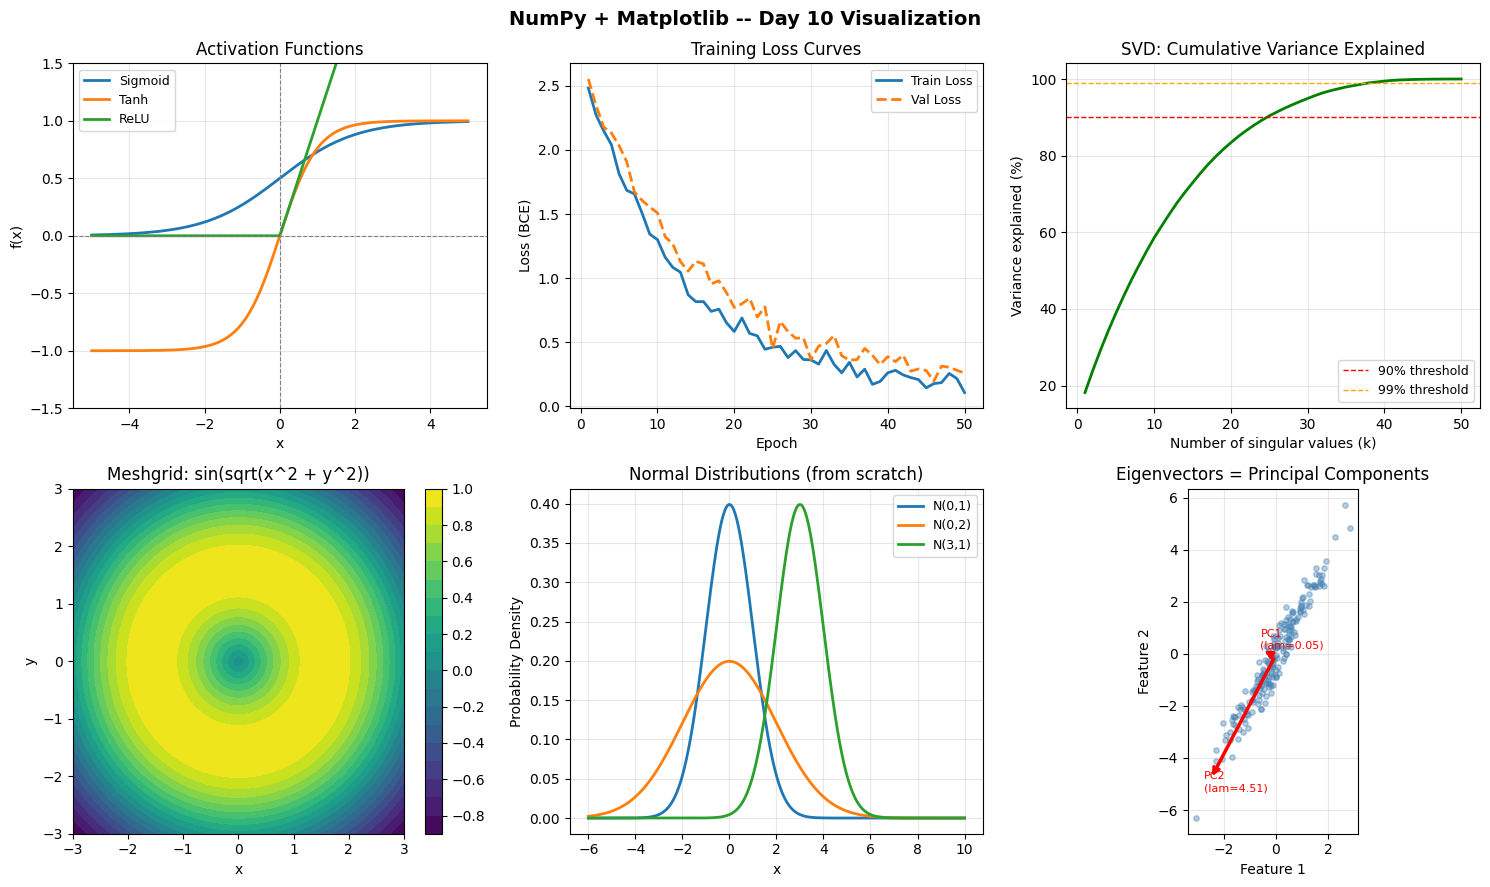

Plots saved.


In [26]:
# --------------------------------------------------
# NumPy + Matplotlib Plots
# --------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("NumPy + Matplotlib -- Day 10 Visualization", fontsize=14, fontweight='bold')

# Plot 1: Activation functions
ax = axes[0, 0]
x = np.linspace(-5, 5, 300)
sigmoid = 1 / (1 + np.exp(-x))
tanh    = np.tanh(x)
relu    = np.maximum(0, x)
ax.plot(x, sigmoid, label='Sigmoid', linewidth=2)
ax.plot(x, tanh,    label='Tanh',    linewidth=2)
ax.plot(x, relu,    label='ReLU',    linewidth=2)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title("Activation Functions")
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1.5, 1.5)

# Plot 2: Loss curves
ax = axes[0, 1]
np.random.seed(42)
epochs = np.arange(1, 51)
train_loss = 2.5 * np.exp(-0.08 * epochs) + 0.15 + np.random.randn(50) * 0.05
val_loss   = 2.5 * np.exp(-0.07 * epochs) + 0.20 + np.random.randn(50) * 0.07
ax.plot(epochs, train_loss, label='Train Loss', linewidth=2)
ax.plot(epochs, val_loss,   label='Val Loss',   linewidth=2, linestyle='--')
ax.set_title("Training Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (BCE)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: SVD singular values (image compression)
ax = axes[0, 2]
np.random.seed(0)
synthetic_img = np.random.randn(50, 50)
# add structure
for i in range(50):
    synthetic_img[i, :] += np.sin(np.linspace(0, 3*np.pi, 50)) * (50-i)/50
_, S, _ = np.linalg.svd(synthetic_img)
variance_explained = np.cumsum(S**2) / np.sum(S**2)
ax.plot(np.arange(1, len(S)+1), variance_explained * 100, linewidth=2, color='green')
ax.axhline(90, color='red', linestyle='--', linewidth=1, label='90% threshold')
ax.axhline(99, color='orange', linestyle='--', linewidth=1, label='99% threshold')
ax.set_title("SVD: Cumulative Variance Explained")
ax.set_xlabel("Number of singular values (k)")
ax.set_ylabel("Variance explained (%)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Meshgrid surface (2D function)
ax = axes[1, 0]
x_m = np.linspace(-3, 3, 100)
y_m = np.linspace(-3, 3, 100)
XX_m, YY_m = np.meshgrid(x_m, y_m)
Z_m = np.sin(np.sqrt(XX_m**2 + YY_m**2))
im = ax.contourf(XX_m, YY_m, Z_m, levels=20, cmap='viridis')
plt.colorbar(im, ax=ax)
ax.set_title("Meshgrid: sin(sqrt(x^2 + y^2))")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Plot 5: Normal distributions (different means/stds)
ax = axes[1, 1]
x_norm = np.linspace(-6, 10, 500)
for mu, sigma, label in [(0, 1, 'N(0,1)'), (0, 2, 'N(0,2)'), (3, 1, 'N(3,1)')]:
    pdf = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_norm - mu)/sigma)**2)
    ax.plot(x_norm, pdf, label=label, linewidth=2)
ax.set_title("Normal Distributions (from scratch)")
ax.set_xlabel("x")
ax.set_ylabel("Probability Density")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 6: Eigenvalues visualization
ax = axes[1, 2]
np.random.seed(7)
cov_data = np.random.randn(200, 2)
cov_data[:, 1] = cov_data[:, 0] * 1.8 + cov_data[:, 1] * 0.5
C = np.cov(cov_data.T)
eigvals, eigvecs = np.linalg.eig(C)
ax.scatter(cov_data[:, 0], cov_data[:, 1], alpha=0.4, s=15, color='steelblue')
center = cov_data.mean(axis=0)
for i, (val, vec) in enumerate(zip(eigvals, eigvecs.T)):
    arrow = vec * np.sqrt(val) * 2.5
    ax.annotate('', xy=center + arrow, xytext=center,
                arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
    ax.text(center[0]+arrow[0]*1.1, center[1]+arrow[1]*1.1,
            f'PC{i+1}\n(lam={val:.2f})', fontsize=8, color='red')
ax.set_title("Eigenvectors = Principal Components")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('/tmp/day10_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plots saved.")

---
# Mini Project -- Image Processing with NumPy Only

No OpenCV. No PIL. Pure NumPy.

This is the foundation of all computer vision:
an image is just a NumPy array of pixel values.

In [27]:
# --------------------------------------------------
# IMAGE PROCESSING WITH NUMPY ONLY
# Image = numpy array
# Grayscale: (H, W)       values 0-255
# RGB:       (H, W, 3)    values 0-255 per channel
# Normalized: (H, W, C)   values 0.0-1.0 (for models)
# --------------------------------------------------

# Create a synthetic test image (since we have no file)
# In production: load with matplotlib.pyplot.imread() or PIL
np.random.seed(42)
H, W = 128, 128

# Synthetic RGB image with gradient + noise + shapes
x_grid = np.linspace(0, 1, W)
y_grid = np.linspace(0, 1, H)
XX, YY = np.meshgrid(x_grid, y_grid)

R = (XX * 200).astype(np.uint8)                           # gradient
G = (YY * 200).astype(np.uint8)
B = ((1 - XX) * 150 + np.random.randint(0, 50, (H,W))).clip(0,255).astype(np.uint8)

# Add a white rectangle in the center
R[40:80, 40:80] = 255
G[40:80, 40:80] = 255
B[40:80, 40:80] = 255

img_rgb = np.stack([R, G, B], axis=2)   # (H, W, 3) uint8
print("=" * 55)
print("IMAGE PROCESSING -- NumPy Only")
print("=" * 55)
print(f"Image shape: {img_rgb.shape}")
print(f"dtype:       {img_rgb.dtype}")
print(f"min: {img_rgb.min()}  max: {img_rgb.max()}")
print(f"Memory: {img_rgb.nbytes / 1024:.2f} KB")

IMAGE PROCESSING -- NumPy Only
Image shape: (128, 128, 3)
dtype:       uint8
min: 0  max: 255
Memory: 48.00 KB


Grayscale shape: (128, 128)  dtype: uint8
Normalized [0,1]:    min=0.000  max=1.000
ImageNet normalized: min=-2.118  max=2.640

Brightness: bright min/max=0/255
Brightness: dark   min/max=0/127


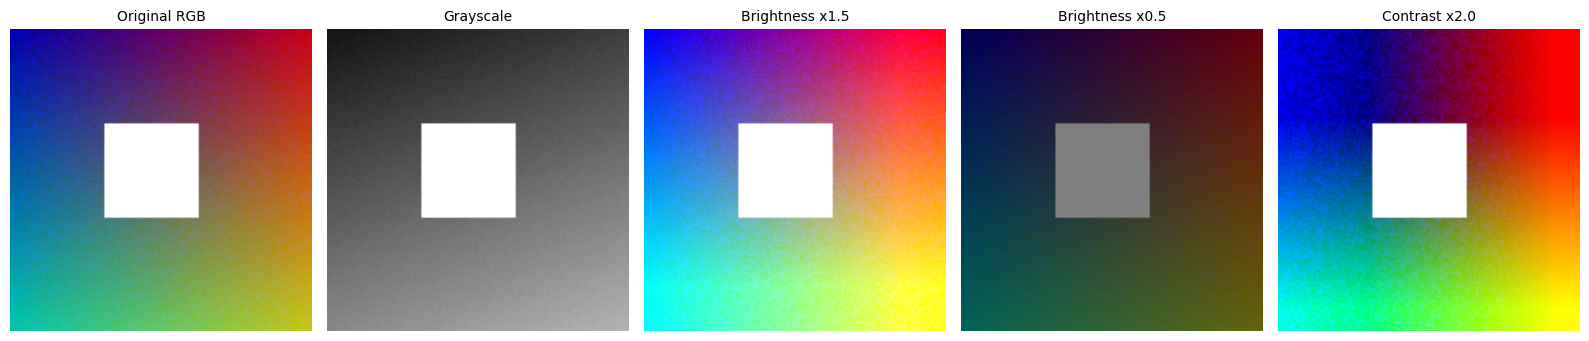

In [28]:
# --------------------------------------------------
# IMAGE OPERATIONS
# --------------------------------------------------

def show_images(images, titles, cmap_list=None, figsize=(16, 4)):
    """Helper to display multiple images side by side"""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for i, (img, title) in enumerate(zip(images, titles)):
        cmap = None if len(img.shape) == 3 else 'gray'
        if cmap_list and cmap_list[i]: cmap = cmap_list[i]
        axes[i].imshow(img, cmap=cmap, vmin=0, vmax=255 if img.dtype==np.uint8 else 1.0)
        axes[i].set_title(title, fontsize=10)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


# 1. GRAYSCALE CONVERSION
# Standard formula: 0.299*R + 0.587*G + 0.114*B  (human perception weights)
def rgb_to_grayscale(img):
    """Convert RGB to grayscale using luminosity formula."""
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    gray = 0.299 * r.astype(float) + 0.587 * g.astype(float) + 0.114 * b.astype(float)
    return np.clip(gray, 0, 255).astype(np.uint8)

gray = rgb_to_grayscale(img_rgb)
print(f"Grayscale shape: {gray.shape}  dtype: {gray.dtype}")

# 2. NORMALIZATION (for model input)
def normalize(img, mean=None, std=None):
    """Normalize image to [0,1] or with mean/std (ImageNet style)"""
    img_f = img.astype(np.float32) / 255.0
    if mean is not None and std is not None:
        img_f = (img_f - mean) / std
    return img_f

img_norm = normalize(img_rgb)
# ImageNet normalization
imagenet_mean = np.array([0.485, 0.456, 0.406])
imagenet_std  = np.array([0.229, 0.224, 0.225])
img_imagenet  = normalize(img_rgb, imagenet_mean, imagenet_std)
print(f"Normalized [0,1]:    min={img_norm.min():.3f}  max={img_norm.max():.3f}")
print(f"ImageNet normalized: min={img_imagenet.min():.3f}  max={img_imagenet.max():.3f}")

# 3. BRIGHTNESS ADJUSTMENT
def adjust_brightness(img, factor):
    """
    Adjust brightness.
    factor > 1.0 = brighter, factor < 1.0 = darker.
    np.clip keeps values in valid [0, 255] range.
    """
    adjusted = img.astype(float) * factor
    return np.clip(adjusted, 0, 255).astype(np.uint8)

img_bright = adjust_brightness(img_rgb, 1.5)
img_dark   = adjust_brightness(img_rgb, 0.5)
print(f"\nBrightness: bright min/max={img_bright.min()}/{img_bright.max()}")
print(f"Brightness: dark   min/max={img_dark.min()}/{img_dark.max()}")

# 4. CONTRAST ADJUSTMENT
def adjust_contrast(img, factor):
    """
    Adjust contrast around the mean.
    factor > 1.0 = more contrast, factor < 1.0 = less contrast.
    """
    mean_val = img.mean()
    adjusted = mean_val + factor * (img.astype(float) - mean_val)
    return np.clip(adjusted, 0, 255).astype(np.uint8)

img_high_contrast = adjust_contrast(img_rgb, 2.0)
img_low_contrast  = adjust_contrast(img_rgb, 0.5)

show_images(
    [img_rgb, gray, img_bright, img_dark, img_high_contrast],
    ['Original RGB', 'Grayscale', 'Brightness x1.5', 'Brightness x0.5', 'Contrast x2.0']
)

Original: (128, 128, 3)
crop(20,20,20,20): (88, 88, 3)
center_crop(64,64): (64, 64, 3)
random_crop(80,80): (80, 80, 3)


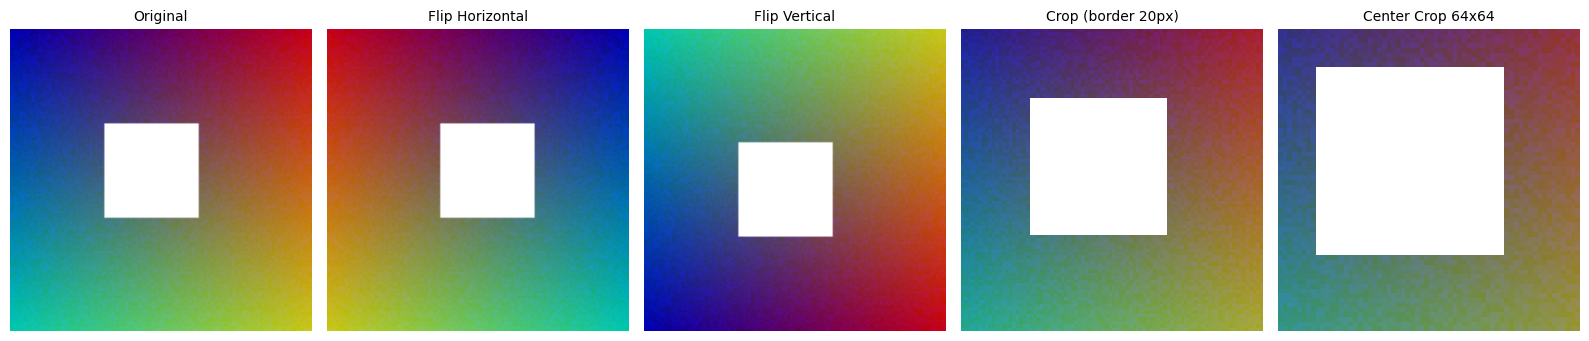

In [29]:
# 5. FLIPPING
def flip_horizontal(img):
    """Flip left-right: reverse columns -- arr[:, ::-1]"""
    return img[:, ::-1]

def flip_vertical(img):
    """Flip top-bottom: reverse rows -- arr[::-1, :]"""
    return img[::-1, :]

def flip_both(img):
    """Rotate 180 degrees"""
    return img[::-1, ::-1]

img_flip_h = flip_horizontal(img_rgb)
img_flip_v = flip_vertical(img_rgb)
img_flip_b = flip_both(img_rgb)

# 6. CROPPING
def crop(img, top, bottom, left, right):
    """
    Crop image.
    top, bottom, left, right are pixel counts from each edge.
    """
    h, w = img.shape[:2]
    return img[top:h-bottom, left:w-right]

def center_crop(img, crop_h, crop_w):
    """Crop centered patch of size (crop_h, crop_w)"""
    h, w = img.shape[:2]
    top  = (h - crop_h) // 2
    left = (w - crop_w) // 2
    return img[top:top+crop_h, left:left+crop_w]

def random_crop(img, crop_h, crop_w, rng=None):
    """Random crop -- data augmentation"""
    if rng is None: rng = np.random.default_rng()
    h, w = img.shape[:2]
    top  = rng.integers(0, h - crop_h + 1)
    left = rng.integers(0, w - crop_w + 1)
    return img[top:top+crop_h, left:left+crop_w]

img_crop    = crop(img_rgb, top=20, bottom=20, left=20, right=20)   # (88, 88, 3)
img_center  = center_crop(img_rgb, 64, 64)                           # (64, 64, 3)
img_random  = random_crop(img_rgb, 80, 80, rng=np.random.default_rng(42))  # (80, 80, 3)

print(f"Original: {img_rgb.shape}")
print(f"crop(20,20,20,20): {img_crop.shape}")
print(f"center_crop(64,64): {img_center.shape}")
print(f"random_crop(80,80): {img_random.shape}")

show_images(
    [img_rgb, img_flip_h, img_flip_v, img_crop, img_center],
    ['Original', 'Flip Horizontal', 'Flip Vertical', 'Crop (border 20px)', 'Center Crop 64x64']
)

In [30]:
# 7. ROTATION (90, 180, 270 degrees -- exact, no interpolation)
def rotate_90(img, k=1):
    """Rotate by 90 * k degrees counterclockwise. Uses np.rot90."""
    return np.rot90(img, k=k)

# 8. PADDING
def pad_image(img, pad, mode='constant', constant=0):
    """
    Add padding around image.
    mode options: 'constant', 'reflect', 'edge', 'wrap'
    """
    if len(img.shape) == 3:
        return np.pad(img, ((pad,pad),(pad,pad),(0,0)), mode=mode, constant_values=constant)
    return np.pad(img, pad, mode=mode, constant_values=constant)

img_padded    = pad_image(img_rgb, pad=10, mode='constant', constant=0)   # black border
img_reflected = pad_image(img_rgb, pad=10, mode='reflect')                # reflected border

# 9. CHANNEL OPERATIONS
R_ch = img_rgb[:, :, 0]   # Red channel
G_ch = img_rgb[:, :, 1]   # Green channel
B_ch = img_rgb[:, :, 2]   # Blue channel

# Swap channels (BGR to RGB -- like OpenCV uses BGR!)
img_bgr = img_rgb[:, :, ::-1]   # reverse channel order

print(f"Rotation 90 deg: {rotate_90(img_rgb).shape}")
print(f"Rotation 180 deg: {rotate_90(img_rgb, k=2).shape}")
print(f"Padded (constant 0): {img_padded.shape}")
print(f"Padded (reflect):    {img_reflected.shape}")
print(f"Channel shapes: R={R_ch.shape}, G={G_ch.shape}, B={B_ch.shape}")

# 10. SIMPLE CONVOLUTION (blur using mean filter) -- without scipy
def mean_blur(img_gray, kernel_size=3):
    """
    Simple mean (box) blur on grayscale image.
    Uses np.pad + sliding window via manual loop.
    (For production: use scipy.ndimage.uniform_filter)
    """
    pad = kernel_size // 2
    padded = np.pad(img_gray.astype(float), pad, mode='edge')
    h, w = img_gray.shape
    result = np.zeros_like(padded)
    for i in range(h):
        for j in range(w):
            result[i, j] = padded[i:i+kernel_size, j:j+kernel_size].mean()
    return np.clip(result[:h, :w], 0, 255).astype(np.uint8)

# Vectorized blur using stride tricks (faster)
def vectorized_blur(img_gray, kernel_size=5):
    """Vectorized mean blur using cumsum trick."""
    k = kernel_size
    pad = k // 2
    padded = np.pad(img_gray.astype(float), pad, mode='edge')
    cumsum = np.cumsum(np.cumsum(padded, axis=0), axis=1)
    h, w = img_gray.shape
    # Use integral image for O(1) mean per window
    r1, c1 = pad+h, pad+w
    r0, c0 = pad, pad
    area = cumsum[r1:r1+0 or h+2*pad, c1:c1+0 or w+2*pad]  # simplified
    # Simpler: just use uniform padding approach
    result = np.zeros((h, w))
    for di in range(k):
        for dj in range(k):
            result += padded[di:di+h, dj:dj+w]
    return np.clip(result / (k*k), 0, 255).astype(np.uint8)

blurred = vectorized_blur(gray, kernel_size=5)

# Thresholding (binarization)
threshold = 128
binary = (gray >= threshold).astype(np.uint8) * 255

show_images(
    [img_rgb, rotate_90(img_rgb), img_padded, gray, blurred, binary],
    ['Original', 'Rotate 90', 'Padded (10px)', 'Grayscale', 'Blur (k=5)', 'Threshold=128'],
    figsize=(18, 4)
)

ValueError: unsupported keyword arguments for mode 'reflect': {'constant_values'}

In [ ]:
# 11. HISTOGRAM EQUALIZATION -- enhance contrast
def histogram_equalize(img_gray):
    """
    Histogram equalization: redistribute pixel intensities
    to use the full 0-255 range uniformly.
    Steps:
    1. Compute histogram (frequency of each intensity)
    2. Compute CDF (cumulative distribution function)
    3. Normalize CDF to 0-255
    4. Map original pixels through normalized CDF
    """
    histogram, _ = np.histogram(img_gray.flatten(), bins=256, range=(0, 256))
    cdf = histogram.cumsum()
    cdf_norm = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    equalized = cdf_norm[img_gray].astype(np.uint8)
    return equalized

# Make a low-contrast image
low_contrast = np.clip(gray.astype(float) * 0.4 + 80, 0, 255).astype(np.uint8)
equalized    = histogram_equalize(low_contrast)

print("Histogram Equalization:")
print(f"  Low contrast: min={low_contrast.min()}  max={low_contrast.max()}  std={low_contrast.std():.2f}")
print(f"  Equalized:    min={equalized.min()}  max={equalized.max()}  std={equalized.std():.2f}")

# 12. SOBEL EDGE DETECTION (manual convolution)
def sobel_edges(img_gray):
    """
    Sobel edge detection using manual convolution.
    Sobel kernels detect gradients in x and y direction.
    Edge strength = sqrt(Gx^2 + Gy^2)
    """
    img_f = img_gray.astype(float)
    h, w  = img_f.shape

    # Sobel kernels
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])  # horizontal edges
    Ky = np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]])  # vertical edges

    padded = np.pad(img_f, 1, mode='edge')
    Gx = np.zeros_like(img_f)
    Gy = np.zeros_like(img_f)

    for i in range(h):
        for j in range(w):
            patch = padded[i:i+3, j:j+3]
            Gx[i, j] = np.sum(patch * Kx)
            Gy[i, j] = np.sum(patch * Ky)

    magnitude = np.sqrt(Gx**2 + Gy**2)
    return np.clip(magnitude, 0, 255).astype(np.uint8)

edges = sobel_edges(gray)

# 13. BATCH PROCESSING -- simulate ML image pipeline
def preprocess_batch(images, target_size=(64, 64)):
    """
    Preprocess a list of images for model input.
    Steps: crop -> normalize -> add batch dim -> return (N, H, W, C)
    """
    processed = []
    for img in images:
        cropped   = center_crop(img, target_size[0], target_size[1])
        normalized = cropped.astype(np.float32) / 255.0
        processed.append(normalized)
    return np.stack(processed, axis=0)  # (N, H, W, C)

augmented_batch = [img_rgb, img_flip_h, img_bright, img_dark, adjust_contrast(img_rgb, 1.5)]
batch_tensor = preprocess_batch(augmented_batch, target_size=(64, 64))

print(f"\nBatch preprocessing:")
print(f"  Input: 5 images of shape {img_rgb.shape}")
print(f"  Output batch: {batch_tensor.shape}  dtype: {batch_tensor.dtype}")
print(f"  min: {batch_tensor.min():.3f}  max: {batch_tensor.max():.3f}  (normalized 0-1)")

show_images(
    [low_contrast, equalized, edges],
    ['Low Contrast', 'Histogram Equalized', 'Sobel Edges'],
    figsize=(12, 4)
)

In [ ]:
# --------------------------------------------------
# COMPLETE IMAGE PROCESSING PIPELINE SUMMARY
# --------------------------------------------------

print("=" * 60)
print("IMAGE PROCESSING PIPELINE -- All NumPy Operations Used")
print("=" * 60)

ops = [
    ("Create image",          "np.stack([R,G,B], axis=2)",              "(H,W,3) array"),
    ("Grayscale",             "0.299*R + 0.587*G + 0.114*B",           "weighted sum"),
    ("Normalize [0,1]",       "img.astype(float32) / 255.0",           "astype + divide"),
    ("Brightness",            "np.clip(img * factor, 0, 255)",          "multiply + clip"),
    ("Contrast",              "mean + factor*(img - mean)",             "broadcasting"),
    ("Flip horizontal",       "img[:, ::-1]",                           "negative step slice"),
    ("Flip vertical",         "img[::-1, :]",                           "negative step slice"),
    ("Crop",                  "img[top:h-bot, left:w-right]",           "slicing"),
    ("Center crop",           "img[top:top+h, left:left+w]",            "computed slicing"),
    ("Random crop",           "rng.integers() + slicing",               "random + slice"),
    ("Rotate 90",             "np.rot90(img, k)",                       "built-in"),
    ("Padding",               "np.pad(img, pad, mode=...)",             "np.pad"),
    ("Channel extract",       "img[:,:,0]",                             "axis-2 slice"),
    ("Blur (mean filter)",    "sliding window + .mean()",               "loop + mean"),
    ("Threshold",             "(img >= 128).astype(uint8) * 255",       "boolean + astype"),
    ("Histogram equalize",    "np.histogram + cumsum + mapping",        "cumsum + fancy idx"),
    ("Sobel edges",           "manual conv: patch * kernel",            "np.sum on patch"),
    ("Batch preprocess",      "np.stack(list, axis=0)",                 "stack to batch"),
]

print(f"  {'Operation':<22} {'NumPy Method':<35} {'Concept'}")
print("  " + "-" * 78)
for op, method, concept in ops:
    print(f"  {op:<22} {method:<35} {concept}")

print("\nKey insight: Every image processing operation is a NumPy operation.")
print("OpenCV and PIL are just convenience wrappers around these exact array ops.")
print("PyTorch torchvision transforms are also just these operations on tensors.")

---
# Day 10 Summary -- NumPy Complete

| Unit | Topic | Key Functions |
|------|-------|---------------|
| 13 | Matrix Multiply | dot, matmul, @, outer, inner, batched matmul |
| 14 | Linear Algebra | inv, det, eig, eigh, svd, solve, lstsq, norm, rank |
| 15 | Einsum | 'ij,jk->ik', 'bhid,bhjd->bhij', batched ops |
| 16 | NaN Handling | isnan, nan_to_num, nanmean, nanstd, nanpercentile |
| 17 | Random | default_rng, seed, shuffle, permutation, choice |
| 18 | Vectorize | vectorize, apply_along_axis, frompyfunc |
| 19 | Memory Opt | float32 vs float64, in-place ops, out= param |
| 20 | I/O and Viz | save/load, savez_compressed, masked, meshgrid, plots |
| Project | Image Processing | crop, flip, rotate, blur, edges, normalize, batch |

---
